Name: Fateh Noor <br>
CMS-ID: 023-24-0110<br>
Section: D<br>
Github: https://github.com/noormangi17/ML-Tasks/tree/main/Lab4<br>

In [1]:
#task 1
import pandas as pd 
import numpy as np 
df=pd.read_csv("clean_churn.csv")
y=df['Churn'].map(
    {'Yes':1,'No':0}
)
x=df.drop(['Churn'],axis=1)
x=pd.get_dummies(x,drop_first=True)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
                        x,y,
                        test_size=0.2,
                        random_state=42,
                        stratify=y)

In [2]:
#task 2
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
tree_best=DecisionTreeClassifier(max_depth=4)
tree_best.fit(x_train,y_train)
pred_best=tree_best.predict(x_test)
accuracy_best=accuracy_score(y_test,pred_best)
precision_best=precision_score(y_test,pred_best)
recall_best=recall_score(y_test,pred_best)
f1_best=f1_score(y_test,pred_best)
print("Accuracy on test data or best selected model: ",round(accuracy_best,4))
print("Precision on test data or best selected model: ",round(precision_best,4))
print("Recall on test data or best selected model: ",round(recall_best,4))
print("F1-Score on test data or best selected model: ",round(f1_best,4))

Accuracy on test data or best selected model:  0.7956
Precision on test data or best selected model:  0.6443
Recall on test data or best selected model:  0.5134
F1-Score on test data or best selected model:  0.5714


In [3]:
#task 3
from sklearn.ensemble import RandomForestClassifier
forest=RandomForestClassifier(n_estimators=200,random_state=42)
forest.fit(x_train,y_train)
forest_pred=forest.predict(x_test)
print(forest_pred)

[0 1 0 ... 0 0 0]


Task 4<br>
A Random Forest may generalize better because it combines predictions from many different decision trees instead of depending on just one tree. This reduces overfitting and makes the model more reliable on unseen data.

Accuracy of Random Forest Classifier:  0.7892
Precsion of Random Forest Classifier:  0.6314
Recall of Random Forest Classifier:  0.4947
F1 Score of Random Forest Classifier:  0.5547


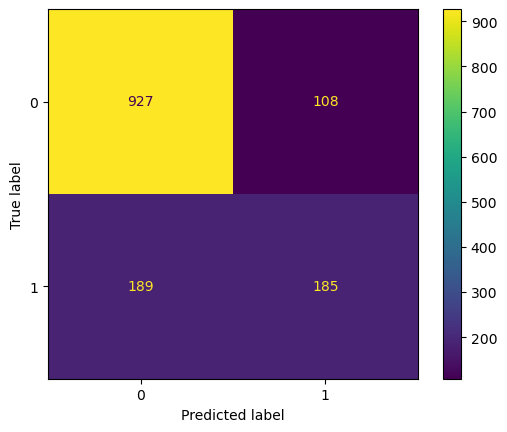

In [4]:
#task5
forest_accuracy=accuracy_score(y_test,forest_pred)
forest_precision=precision_score(y_test,forest_pred)
forest_recall=recall_score(y_test,forest_pred)
forest_f1=f1_score(y_test,forest_pred)
print("Accuracy of Random Forest Classifier: ",round(forest_accuracy,4))
print("Precsion of Random Forest Classifier: ",round(forest_precision,4))
print("Recall of Random Forest Classifier: ",round(forest_recall,4))
print("F1 Score of Random Forest Classifier: ",round(forest_f1,4))
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
cm=confusion_matrix(y_test,forest_pred)
ConfusionMatrixDisplay(cm).plot()

Task 6 <br>
| Metric | Decision Tree | Random Forest |
|---:|---:|---:|
|Accuracy|0.7956|0.6892|
|Precsion|0.6443|0.6314|
|Recall|0.5134|0.4947|
|F1 Score|0.5714|0.5547|

Task 7 <br>
The Decision Tree performs better overall. Its accuracy advantage is large, but the other metric differences are small. Because of class imbalance, F1 Score (and recall) matters more than accuracy.

In [5]:
#task8
from sklearn.model_selection import cross_val_score
tree_cross=cross_val_score(tree_best,x_test,y_test,cv=5,scoring='f1')
forest_cross=cross_val_score(forest,x_test,y_test,cv=5,scoring='f1')
print("Mean of Decision Tree Fold Scores: ",round(tree_cross.mean(),4))
print("Mean of Radnom Forest Fold Scores: ",round(forest_cross.mean(),4))
print("Standard Deviation of Decision Tree Fold Scores: ",round(tree_cross.std(),4))
print("Standard Deviation of Random Forest Fold Scores: ",round(forest_cross.std(),4))

Mean of Decision Tree Fold Scores:  0.5546
Mean of Radnom Forest Fold Scores:  0.5462
Standard Deviation of Decision Tree Fold Scores:  0.0481
Standard Deviation of Random Forest Fold Scores:  0.0342


Task 9<br>
Cross-validation gives very similar results to the single train/test split. The Decision Tree still performs slightly better (F1 = 0.5546) than the Random Forest (F1 = 0.5462), but the difference is very small. So, the cross-validation results do not change the conclusion that the Decision Tree is slightly better, but they make us less confident that the difference is significant.

In [6]:
#task10
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
param_grid={'n_estimators':[100,200,300],'max_depth':[2,4,6,10],'min_samples_split':[2,5]}
grid_search=GridSearchCV(forest,param_grid,cv=5,scoring='f1')
grid_search.fit(x_train,y_train)
print("best Parameters: ",grid_search.best_params_)
print("best Estimator: ",grid_search.best_estimator_)
print("best Score: ",round(grid_search.best_score_,4))

best Parameters:  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
best Estimator:  RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)
best Score:  0.5659


### Task 11 
The best Random Forest model uses 200 trees, a maximum depth of 10, and a minimum of 5 samples for splitting. It achieved a cross-validated F1 score of 0.5659.

In [10]:
#task12
rf_tuned=RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_split=2,random_state=42)
rf_tuned.fit(x_train,y_train)
tuned_pred=rf_tuned.predict(x_test)
tuned_accuracy=accuracy_score(y_test,tuned_pred)
tuned_precision=precision_score(y_test,tuned_pred)
tuned_recall=recall_score(y_test,tuned_pred)
tuned_f1=f1_score(y_test,tuned_pred)
print("Accuracy of Tuned Model: ",round(tuned_accuracy,4))
print("Precision of Tuned Model: ",round(tuned_precision,4))
print("Recall of Tuned Model: ",round(tuned_recall,4))
print("F1 Score of Tuned Model: ",round(tuned_f1,4))

Accuracy of Tuned Model:  0.8048
Precision of Tuned Model:  0.6645
Recall of Tuned Model:  0.5348
F1 Score of Tuned Model:  0.5926


Task 13 <br>
| Metric | Decision Tree | Default Random Forest | Tuned Random Forest |
|---:|---:|---:|---:|
|Accuracy|0.7956|0.6892|0.8048|
|Precsion|0.6443|0.6314|0.6645|
|Recall|0.5134|0.4947|0.5348|
|F1 Score|0.5714|0.5547|0.5926|

### Task 14
Final model: Tuned Random Forest. It has the highest Accuracy (0.8048), Precision (0.6645), Recall (0.5348), and F1 Score (0.5926) among the three models. Its highest F1 Score and Recall show better overall performance in identifying churn cases. Therefore, the Tuned Random Forest is selected as the final model.

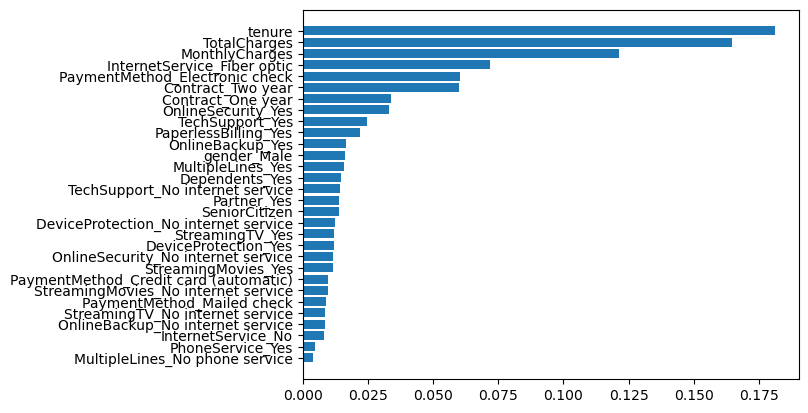

In [12]:
#task15
importances=rf_tuned.feature_importances_
importances=pd.Series(importances,index=x.columns).sort_values()
import matplotlib.pyplot as plt
plt.barh(importances.index,importances.values)
plt.show()

The 5 most important features in the final Tuned Random Forest are tenure, TotalCharges, MonthlyCharges, InternetService_Fiber optic, and PaymentMethod_Electronic check. These results mostly agree with Lab 2 EDA because tenure, InternetService, and monthly charges were related to churn. They also partly agree with Lab 3's Decision Tree, where InternetService, TotalCharges, tenure, and PaymentMethod were important features. Thus, the feature importance results are generally consistent with the previous analysis.

In [13]:
#Task 16 
y_pred=rf_tuned.predict(x_test)
y_pred=pd.Series(y_pred).map({
            0:"No",
            1:"Yes"
})
submission=pd.DataFrame({
    "Customer id":x_test.index,
    "Churn":y_pred
})
submission.to_csv("submission.csv",index=False)

### Task 17
I ultimately chose the Tuned Random Forest as my final model. It achieved 80.48% accuracy and an F1-score of 0.5926, which were higher than the Decision Tree and Default Random Forest. The tuned model also had the highest precision (0.6645) and recall (0.5348) among the three models. The main limitation is that the recall is still relatively low, so the model misses some customers who actually churn. Another limitation is the class imbalance in the dataset, which makes predicting the minority Churn class more difficult.

Task 18 <br>
If I had more time, I would try different values of hyperparameters to improve the Decision Tree and Random Forest models. I would also try to handle the class imbalance so that the model can identify more customers who are likely to churn. I would compare the models using F1-score and recall and select the model that performs better on these metrics.